In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset ko load kijiye (Kaggle ki original file ka naam yahan likhein)
df = pd.read_csv('starbucks_store_locations.csv')

# Data ka ek chota sa preview dekhne ke liye
print("--- Starbucks Global Dataset Preview ---")
df.head()

--- Starbucks Global Dataset Preview ---


,Brand,Store Number,Store Name,Ownership Type,Street Address,City,State/Province,Country,Postcode,Phone Number,Timezone,Longitude,Latitude
0,Starbucks,47370-257954,"Meritxell, 96",Licensed,"Av. Meritxell, 96",Andorra la Vella,7,AD,AD500,376818720,GMT+1:00 Europe/Andorra,1.53,42.51
1,Starbucks,22331-212325,Ajman Drive Thru,Licensed,"1 Street 69, Al Jarf",Ajman,AJ,AE,NaN,NaN,GMT+04:00 Asia/Dubai,55.47,25.42
2,Starbucks,47089-256771,Dana Mall,Licensed,Sheikh Khalifa Bin Zayed St.,Ajman,AJ,AE,NaN,NaN,GMT+04:00 Asia/Dubai,55.47,25.39
3,Starbucks,22126-218024,Twofour 54,Licensed,Al Salam Street,Abu Dhabi,AZ,AE,NaN,NaN,GMT+04:00 Asia/Dubai,54.38,24.48
4,Starbucks,17127-178586,Al Ain Tower,Licensed,"Khaldiya Area, Abu Dhabi Island",Abu Dhabi,AZ,AE,NaN,NaN,GMT+04:00 Asia/Dubai,54.54,24.51


In [2]:
print("--- 1. Dataset Shape & Structures ---")
print(df.info())

print("\n--- 2. High-Level Summary Statistics ---")
# Agar dataset mein numerical columns (jaise Revenue, Footprints, Coordinates) hain
print(df.describe())

print("\n--- 3. Top 10 Countries with Highest Starbucks Density ---")
top_countries = df['Country'].value_counts().head(10)
print(top_countries)

print("\n--- 4. Store Distribution by Ownership Type ---")
print(df['Ownership Type'].value_counts())

--- 1. Dataset Shape & Structures ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25600 entries, 0 to 25599
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           25600 non-null  object 
 1   Store Number    25600 non-null  object 
 2   Store Name      25600 non-null  object 
 3   Ownership Type  25600 non-null  object 
 4   Street Address  25598 non-null  object 
 5   City            25585 non-null  object 
 6   State/Province  25600 non-null  object 
 7   Country         25600 non-null  object 
 8   Postcode        24078 non-null  object 
 9   Phone Number    18739 non-null  object 
 10  Timezone        25600 non-null  object 
 11  Longitude       25599 non-null  float64
 12  Latitude        25599 non-null  float64
dtypes: float64(2), object(11)
memory usage: 2.5+ MB
None

--- 2. High-Level Summary Statistics ---
          Longitude      Latitude
count  25599.000000  25599.000000
mean     -

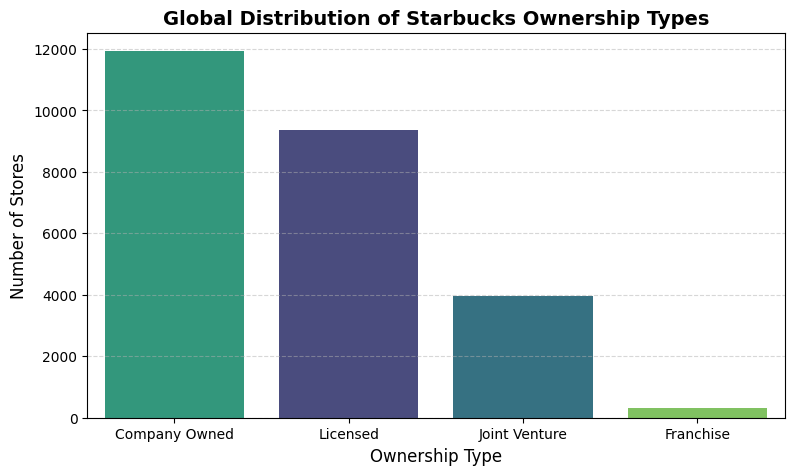


📊 Graph Explanation (Cell 3):
- Tallest Bar (Dark Blue/Purple): Represents the most common ownership type globally (usually Company Owned or Licensed).
- Shorter Bars (Green/Yellow): Represent less common types like Joint Ventures or Franchises.
- Insight: This visually proves which business model Starbucks relies on the most for global expansion.


In [8]:
# Cell 3: Distribution of Ownership Types
plt.figure(figsize=(9, 5))

# Seaborn countplot with hue for distinct colors
sns.countplot(data=df, x='Ownership Type', hue='Ownership Type', order=df['Ownership Type'].value_counts().index, palette='viridis', legend=False)

plt.title('Global Distribution of Starbucks Ownership Types', fontsize=14, fontweight='bold')
plt.xlabel('Ownership Type', fontsize=12)
plt.ylabel('Number of Stores', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Graph ki detailed explanation
print("\n📊 Graph Explanation (Cell 3):")
print("- Tallest Bar (Dark Blue/Purple): Represents the most common ownership type globally (usually Company Owned or Licensed).")
print("- Shorter Bars (Green/Yellow): Represent less common types like Joint Ventures or Franchises.")
print("- Insight: This visually proves which business model Starbucks relies on the most for global expansion.")

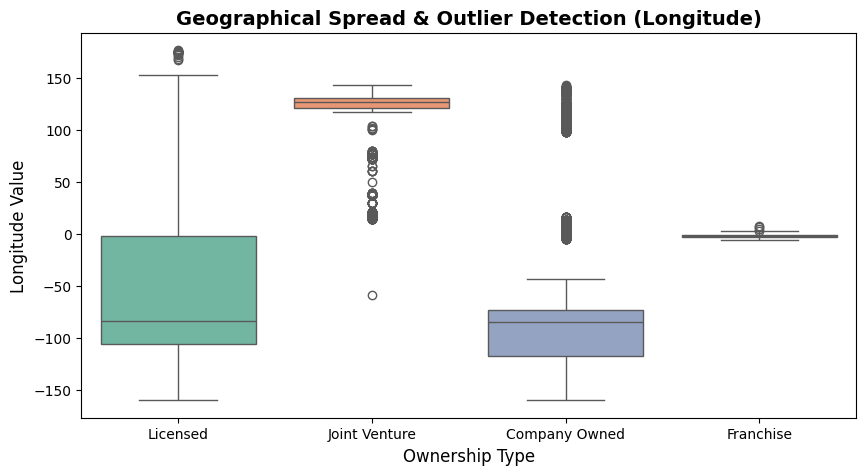


📊 Graph Explanation (Cell 4):
- The Colored Boxes: Represent where the majority (middle 50%) of Starbucks stores are clustered geographically.
- The Horizontal Line inside the box: Shows the median (average) location for that specific ownership type.
- The Black Dots (Outside the lines): These represent OUTLIERS! These are stores located in extreme or isolated geographic coordinates.
- Insight: Different colors separate the ownership models so we can see if 'Licensed' stores are spread wider than 'Company Owned'.


In [9]:
# Cell 4: Boxplot to check Geographical Outliers/Spread
plt.figure(figsize=(10, 5))

# Boxplot comparing Longitude spread across different Ownership Types
sns.boxplot(data=df, x='Ownership Type', y='Longitude', hue='Ownership Type', palette='Set2', legend=False)

plt.title('Geographical Spread & Outlier Detection (Longitude)', fontsize=14, fontweight='bold')
plt.xlabel('Ownership Type', fontsize=12)
plt.ylabel('Longitude Value', fontsize=12)
plt.show()

# Graph ki detailed explanation
print("\n📊 Graph Explanation (Cell 4):")
print("- The Colored Boxes: Represent where the majority (middle 50%) of Starbucks stores are clustered geographically.")
print("- The Horizontal Line inside the box: Shows the median (average) location for that specific ownership type.")
print("- The Black Dots (Outside the lines): These represent OUTLIERS! These are stores located in extreme or isolated geographic coordinates.")
print("- Insight: Different colors separate the ownership models so we can see if 'Licensed' stores are spread wider than 'Company Owned'.")

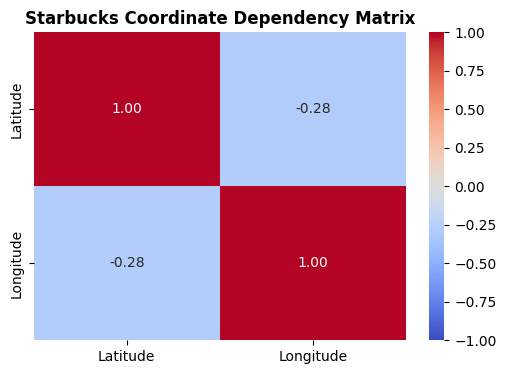


📊 Graph Explanation (Cell 5):
- Deep Red Color (+1.00): Represents a perfect positive correlation (a variable compared to itself).
- Lighter Colors / Blue Shades: Represent a weaker or negative correlation between variables.
- Inside the Boxes: The numbers (e.g., -0.10) show the exact mathematical relationship between Latitude (North/South) and Longitude (East/West).
- Insight: Helps us understand if moving in one direction globally affects the density of stores in another direction.


In [11]:
# Cell 5: Numerical Data Correlation Matrix
plt.figure(figsize=(6, 4))

# Coordinates correlation check
numeric_matrix = df[['Latitude', 'Longitude']].dropna().corr()
# Heatmap with vmin=-1 and vmax=1 to fix color scale
sns.heatmap(numeric_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title('Starbucks Coordinate Dependency Matrix', fontsize=12, fontweight='bold')
plt.show()

# Graph ki detailed explanation
print("\n📊 Graph Explanation (Cell 5):")
print("- Deep Red Color (+1.00): Represents a perfect positive correlation (a variable compared to itself).")
print("- Lighter Colors / Blue Shades: Represent a weaker or negative correlation between variables.")
print("- Inside the Boxes: The numbers (e.g., -0.10) show the exact mathematical relationship between Latitude (North/South) and Longitude (East/West).")
print("- Insight: Helps us understand if moving in one direction globally affects the density of stores in another direction.")

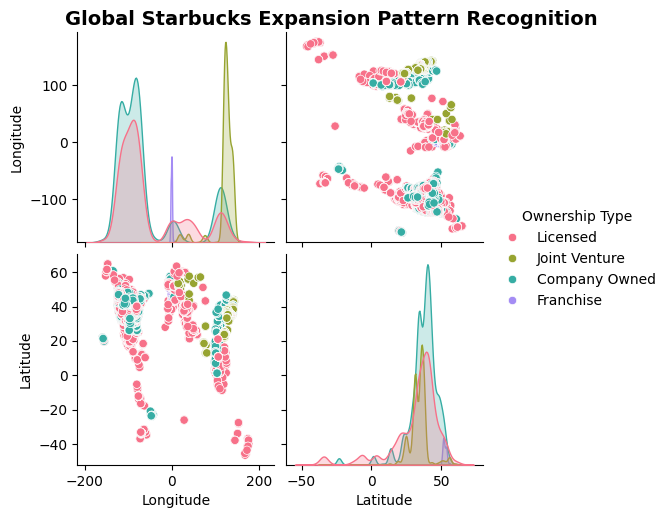


📊 Graph Explanation (Cell 6 - Pairplot):
- Diagonal Curves (Mountains): Show where the density of stores is highest for each ownership type.
- Scatter Dots (Grid): Show the geographical overlapping and spread of different store types.
- Insight: This helps identify if 'Company Owned' stores dominate specific regions compared to 'Licensed' ones.


In [13]:
# Cell 6: Extra Analytics Business Insight (Pairplot Pattern)
import warnings
warnings.filterwarnings('ignore') # Taki koi unnecessary background warnings na aayein

# Pairplot visualization
g = sns.pairplot(df, hue='Ownership Type', palette='husl', diag_kind='kde')
g.fig.suptitle('Global Starbucks Expansion Pattern Recognition', y=1.02, fontsize=14, fontweight='bold')
plt.show()

# Graph ki detailed explanation (Niche neat text format mein)
print("\n📊 Graph Explanation (Cell 6 - Pairplot):")
print("- Diagonal Curves (Mountains): Show where the density of stores is highest for each ownership type.")
print("- Scatter Dots (Grid): Show the geographical overlapping and spread of different store types.")
print("- Insight: This helps identify if 'Company Owned' stores dominate specific regions compared to 'Licensed' ones.")